# Import thư viện

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import chi2

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Tải stopwords nếu chưa có
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

import re
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stopwords = {
    "said", "reuters", "ap", "s", "new",
    "say", "says", "would", "could", "also"
}

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**The class ids are numbered 1-4 where 1 represents World, 2 represents Sports, 3 represents Business and 4 represents Sci/Tech.**

# Load data

**Dữ liệu ban đầu**

In [102]:
train_path = "/content/train.csv"
test_path = "/content/test.csv"

cols = ['label', 'title', 'description']

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.columns = cols
test_df.columns = cols

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (120000, 3)
Test shape: (7600, 3)


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


**Gộp dữ liệu và phân chia lại**

In [103]:
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
df['text'] = df['title'] + ' ' + df['description']
df = df[['label', 'text']]

print(f"Tổng số mẫu sau khi gộp: {len(df)}")
print(f"Phân phối nhãn:\n{df['label'].value_counts().sort_index()}")

Tổng số mẫu sau khi gộp: 127600
Phân phối nhãn:
label
1    31900
2    31900
3    31900
4    31900
Name: count, dtype: int64


In [104]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = pd.DataFrame({'text': X_train, 'label': y_train}).reset_index(drop=True)
test_df = pd.DataFrame({'text': X_test, 'label': y_test}).reset_index(drop=True)

# Kiểm tra kích thước
print(f"Kích thước tập train mới: {len(train_df)} (80%)")
print(f"Kích thước tập test mới: {len(test_df)} (20%)")
print("\nPhân phối nhãn trên tập train mới:")
print(train_df['label'].value_counts().sort_index())
print("\nPhân phối nhãn trên tập test mới:")
print(test_df['label'].value_counts().sort_index())

Kích thước tập train mới: 102080 (80%)
Kích thước tập test mới: 25520 (20%)

Phân phối nhãn trên tập train mới:
label
1    25520
2    25520
3    25520
4    25520
Name: count, dtype: int64

Phân phối nhãn trên tập test mới:
label
1    6380
2    6380
3    6380
4    6380
Name: count, dtype: int64


In [105]:
train_set = set(train_df['text'])
test_set = set(test_df['text'])

overlap = train_set.intersection(test_set)

print("Number of overlapping samples:", len(overlap))

Number of overlapping samples: 0


In [106]:
del df
del test_df

In [107]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102080 entries, 0 to 102079
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    102080 non-null  object
 1   label   102080 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ MB


In [108]:
train_df.sample(5)

,text,label
15523,Thousands to attend Moscow anti-terror rally O...,1
33849,Three Share First-Round Lead at Tradition (AP)...,2
51287,"Cisco, Juniper Making Noise in High-End Routin...",4
93325,"JPMorgan, CSFB to Buy UK Drugmaker Warner Chil...",3
70398,Maximizing your notebook's battery power Tips ...,4


#

# EDA Chất lượng dữ liệu

## Check NULL và DUP

In [109]:
print("Missing values:\n", train_df.isnull().sum())

Missing values:
 text     0
label    0
dtype: int64


In [110]:
content_duplicates = train_df.duplicated(subset=['text']).sum()
print(f"Số lượng trùng lặp nội dung: {content_duplicates}")

Số lượng trùng lặp nội dung: 0


In [111]:
train_df[train_df['text'].str.contains('""')]

,text,label
12766,Lucas to Receive AFI Lifetime Award LOS ANGELE...,1
22269,Wireless San Francisco \\Reuters has a story ...,4
23493,Biotech's 5 Baggers How can yesterday's biotec...,3
67348,"Emmys to Have New Look, Same Matchups LOS ANGE...",1
101389,"Hello Canada! \\Reuters reports:\\""OTTAWA (Reu...",4


- Lỗi dính từ (Missing Spaces)
- Rác HTML/XML (HTML Tags Leakage)
- Ký tự Escape và Backslash dư thừa

## Phân phối nhãn

Phân phối lớp:
label
1    25520
2    25520
3    25520
4    25520
Name: count, dtype: int64


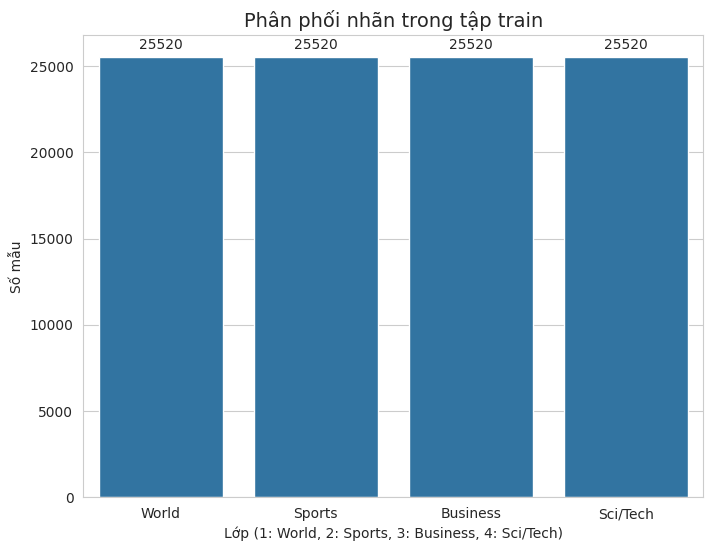

In [112]:
class_counts = train_df['label'].value_counts().sort_index()
print("Phân phối lớp:")
print(class_counts)

# Vẽ biểu đồ
plt.figure(figsize=(8,6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Phân phối nhãn trong tập train', fontsize=14)
plt.xlabel('Lớp (1: World, 2: Sports, 3: Business, 4: Sci/Tech)')
plt.ylabel('Số mẫu')
plt.xticks(ticks=range(4), labels=['World','Sports','Business','Sci/Tech'])
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

## Text length features

--- THỐNG KÊ CHIỀU DÀI VĂN BẢN ---
mean     37.855437
50%      37.000000
min       4.000000
max     177.000000
Name: word_count, dtype: float64

--- NGƯỠNG CẮT (PERCENTILES) ---
90% bài báo có độ dài <= 48 từ
95% bài báo có độ dài <= 53 từ
99% bài báo có độ dài <= 70 từ


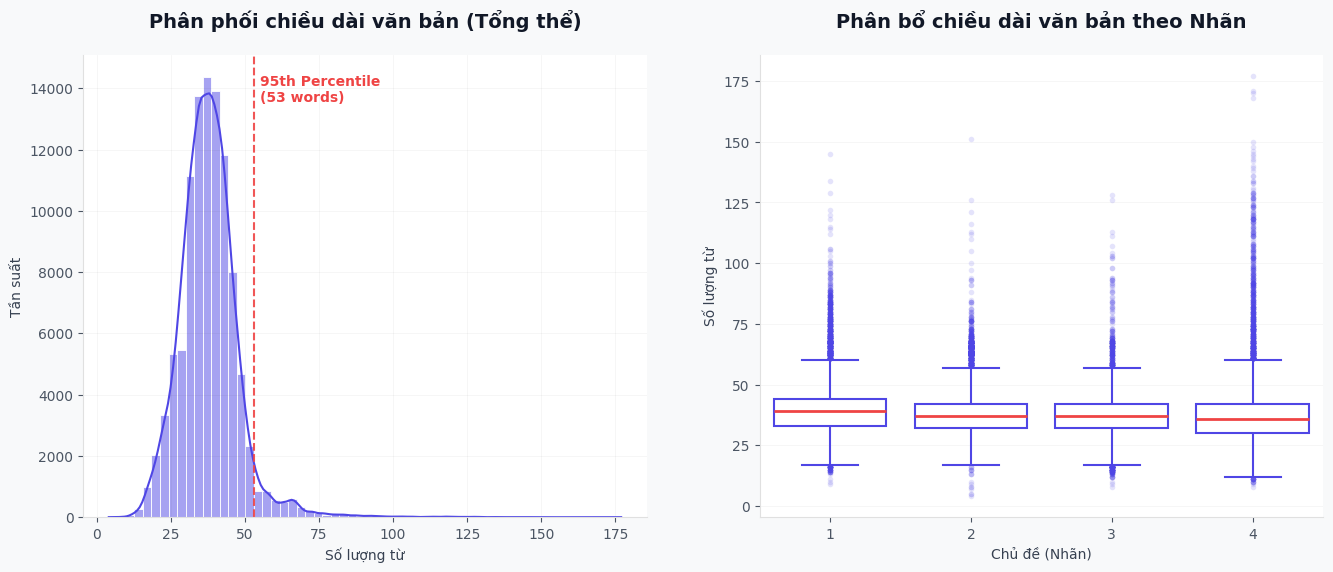

In [113]:
# ---------------------------------------------------------
# 1. TÍNH TOÁN SỐ TỪ BẰNG VECTOR HÓA (Tối ưu tốc độ)
# ---------------------------------------------------------
train_df['word_count'] = train_df['text'].str.split().str.len()

# ---------------------------------------------------------
# 2. TRÍCH XUẤT THỐNG KÊ MÔ TẢ & TÌM NGƯỠNG CẮT (CUT-OFF)
# ---------------------------------------------------------
print("--- THỐNG KÊ CHIỀU DÀI VĂN BẢN ---")
print(train_df['word_count'].describe()[['mean', '50%', 'min', 'max']])

p90 = train_df['word_count'].quantile(0.90)
p95 = train_df['word_count'].quantile(0.95)
p99 = train_df['word_count'].quantile(0.99)

print("\n--- NGƯỠNG CẮT (PERCENTILES) ---")
print(f"90% bài báo có độ dài <= {p90:.0f} từ")
print(f"95% bài báo có độ dài <= {p95:.0f} từ")
print(f"99% bài báo có độ dài <= {p99:.0f} từ")

# ---------------------------------------------------------
# 3. TRỰC QUAN HÓA PHÂN PHỐI (Modern Light Minimalist)
# ---------------------------------------------------------
# Khôi phục cài đặt mặc định để xóa nền đen trước đó
plt.style.use('default')

# Tạo figure với nền màu xám rất nhạt, tạo cảm giác dịu mắt
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#F8F9FA')
fig.subplots_adjust(wspace=0.2)

# Xóa viền trên và phải, làm nhạt viền dưới/trái và lưới (zero clutter)
for ax in axes:
    ax.set_facecolor('#FFFFFF') # Lòng đồ thị màu trắng tinh
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#E0E0E0')
    ax.spines['bottom'].set_color('#E0E0E0')
    ax.grid(color='#000000', alpha=0.05, linestyle='-', linewidth=0.5)

    # Định dạng lại màu chữ cho hài hòa
    ax.tick_params(colors='#4B5563')
    ax.xaxis.label.set_color('#374151')
    ax.yaxis.label.set_color('#374151')

# Biểu đồ 1: Histogram phân phối độ dài toàn tập dữ liệu
sns.histplot(data=train_df, x='word_count', bins=60, kde=True,
             color='#4F46E5', edgecolor='#FFFFFF', ax=axes[0])

# Vẽ đường phân vị 95th bằng màu đỏ để làm nổi bật trên nền sáng
axes[0].axvline(p95, color='#EF4444', linestyle='--', linewidth=1.5, alpha=0.9)
axes[0].text(p95 + 2, axes[0].get_ylim()[1]*0.9, f'95th Percentile\n({p95:.0f} words)',
             color='#EF4444', fontweight='bold')

axes[0].set_title('Phân phối chiều dài văn bản (Tổng thể)', pad=20, fontsize=14, color='#111827', fontweight='bold')
axes[0].set_xlabel('Số lượng từ')
axes[0].set_ylabel('Tần suất')

# Biểu đồ 2: Boxplot kiểm tra sự phân tán theo từng nhãn cụ thể
sns.boxplot(data=train_df, x='label', y='word_count',
            color='#FFFFFF',
            boxprops=dict(edgecolor='#4F46E5', linewidth=1.5),
            whiskerprops=dict(color='#4F46E5', linewidth=1.5),
            capprops=dict(color='#4F46E5', linewidth=1.5),
            medianprops=dict(color='#EF4444', linewidth=2), # Đường trung vị màu đỏ
            flierprops=dict(marker='o', markerfacecolor='#4F46E5', markersize=4, alpha=0.15, markeredgecolor='none'),
            ax=axes[1])

axes[1].set_title('Phân bổ chiều dài văn bản theo Nhãn', pad=20, fontsize=14, color='#111827', fontweight='bold')
axes[1].set_xlabel('Chủ đề (Nhãn)')
axes[1].set_ylabel('Số lượng từ')

plt.show()

In [114]:
for label in [1,2,3,4]:
    subset = train_df[train_df['label'] == label]
    print(f"Class {label}: mean={subset['word_count'].mean():.1f}, "
          f"95th={subset['word_count'].quantile(0.95):.1f}")

Class 1: mean=38.9, 95th=55.0
Class 2: mean=37.8, 95th=52.0
Class 3: mean=37.5, 95th=50.0
Class 4: mean=37.2, 95th=56.0


- Có thể chọn Max len = 64
- Không có văn bản nào vượt qua giới hạn của BERT (512 tokens)

## Từ vựng và tần suất từ

In [115]:
# Hàm tokenize đơn giản (chưa lọc stopword)
def simple_tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Gộp toàn bộ từ
all_tokens = []
train_df['tokens'] = train_df['text'].apply(simple_tokenize)
for tokens in train_df['tokens']:
    all_tokens.extend(tokens)

# Tổng số từ duy nhất, Type-Token Ratio
unique_words = set(all_tokens)
TTR = len(unique_words) / len(all_tokens)
print(f"Tổng số từ: {len(all_tokens)}")
print(f"Số từ duy nhất: {len(unique_words)}")
print(f"Type-Token Ratio: {TTR:.4f}")

Tổng số từ: 4048855
Số từ duy nhất: 61373
Type-Token Ratio: 0.0152


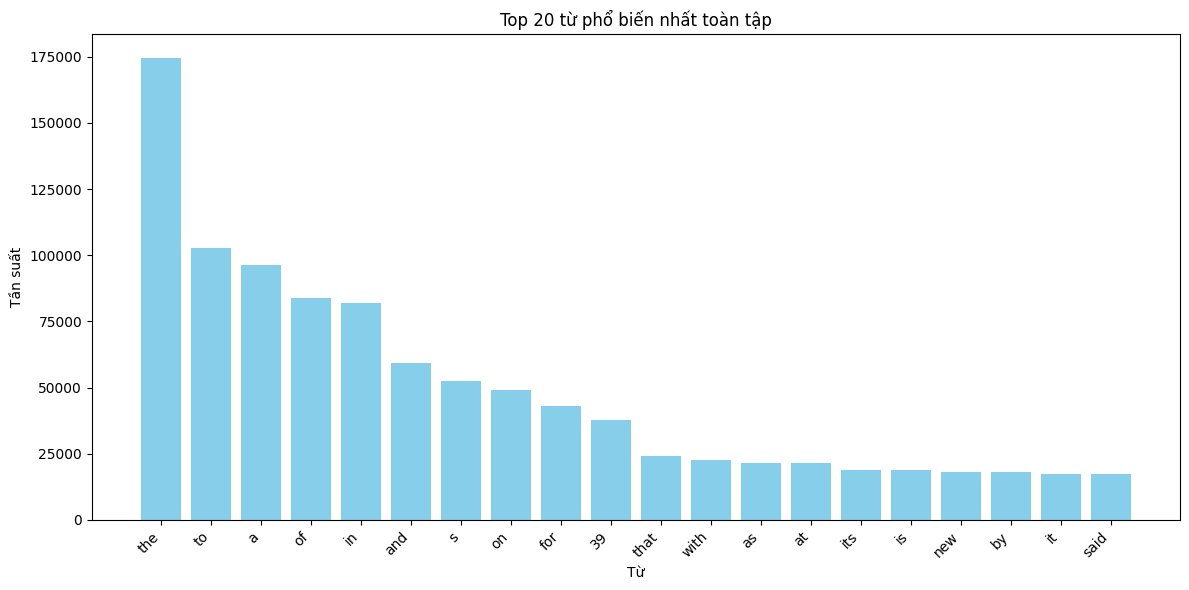

In [116]:
word_freq = Counter(all_tokens)
top20 = word_freq.most_common(20)
words, freqs = zip(*top20)

plt.figure(figsize=(12, 6))
plt.bar(words, freqs, color='skyblue')
plt.xlabel('Từ')
plt.ylabel('Tần suất')
plt.title('Top 20 từ phổ biến nhất toàn tập')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

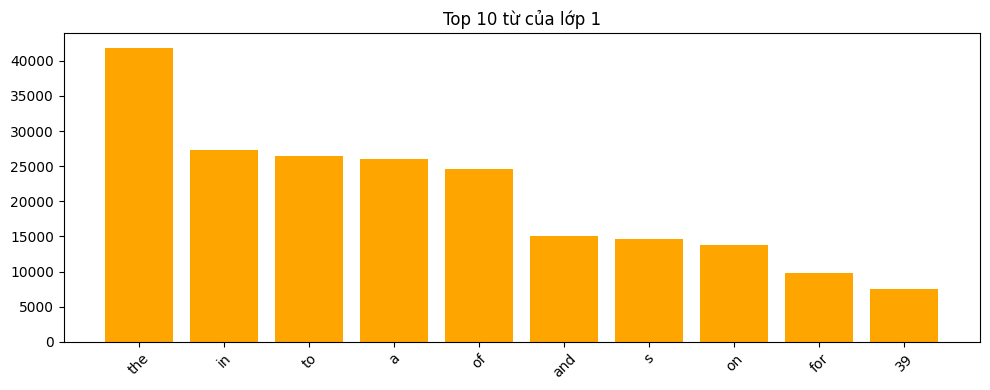

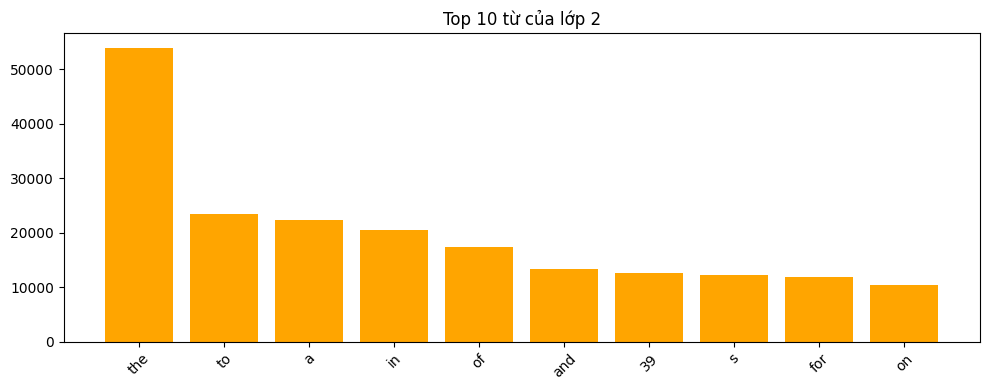

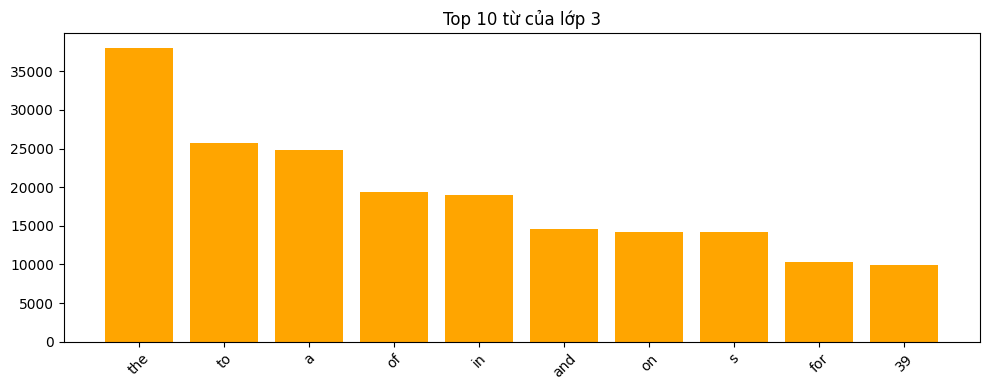

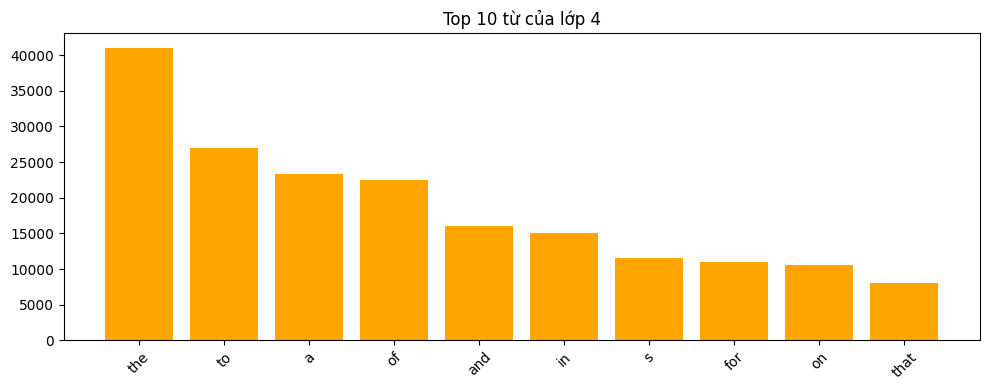

In [117]:
from collections import defaultdict
class_word_freq = defaultdict(Counter)
for idx, row in train_df.iterrows():
    class_idx = row['label']
    class_word_freq[class_idx].update(row['tokens'])

classes = sorted(class_word_freq.keys())
n_classes = len(classes)

for cls in sorted(class_word_freq.keys()):
    top10 = class_word_freq[cls].most_common(10)
    words, freqs = zip(*top10)
    plt.figure(figsize=(10, 4))
    plt.bar(words, freqs, color='orange')
    plt.title(f'Top 10 từ của lớp {cls}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## N-grams

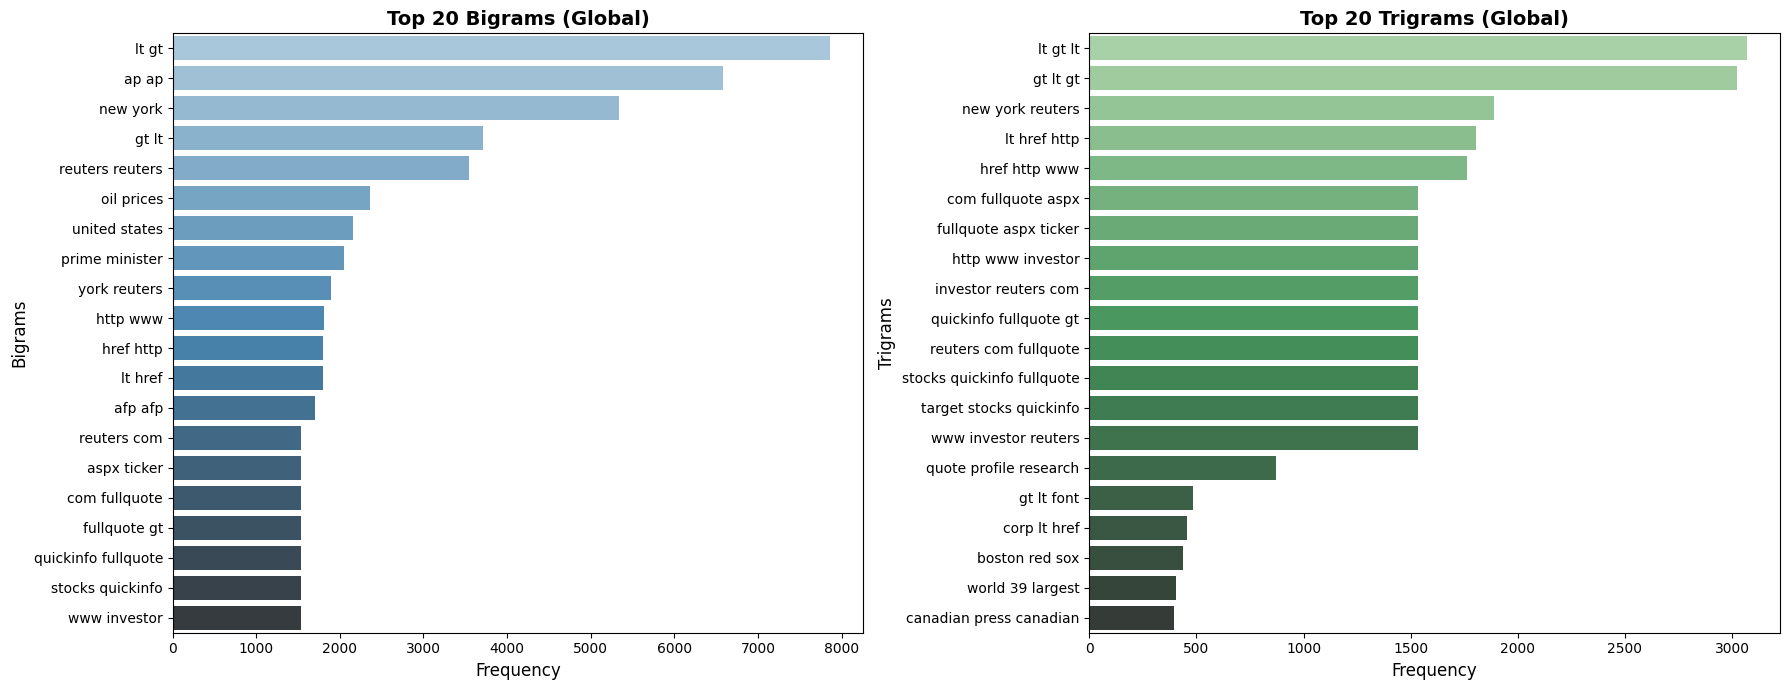

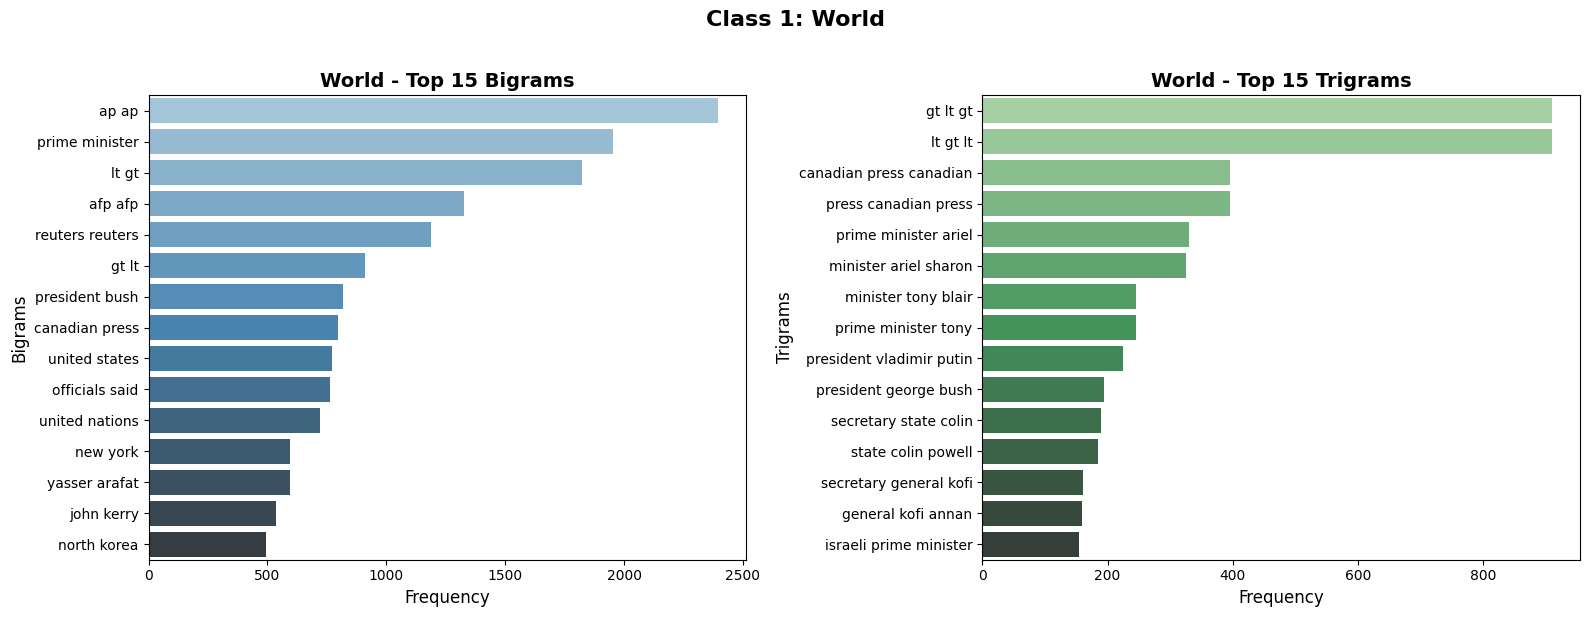

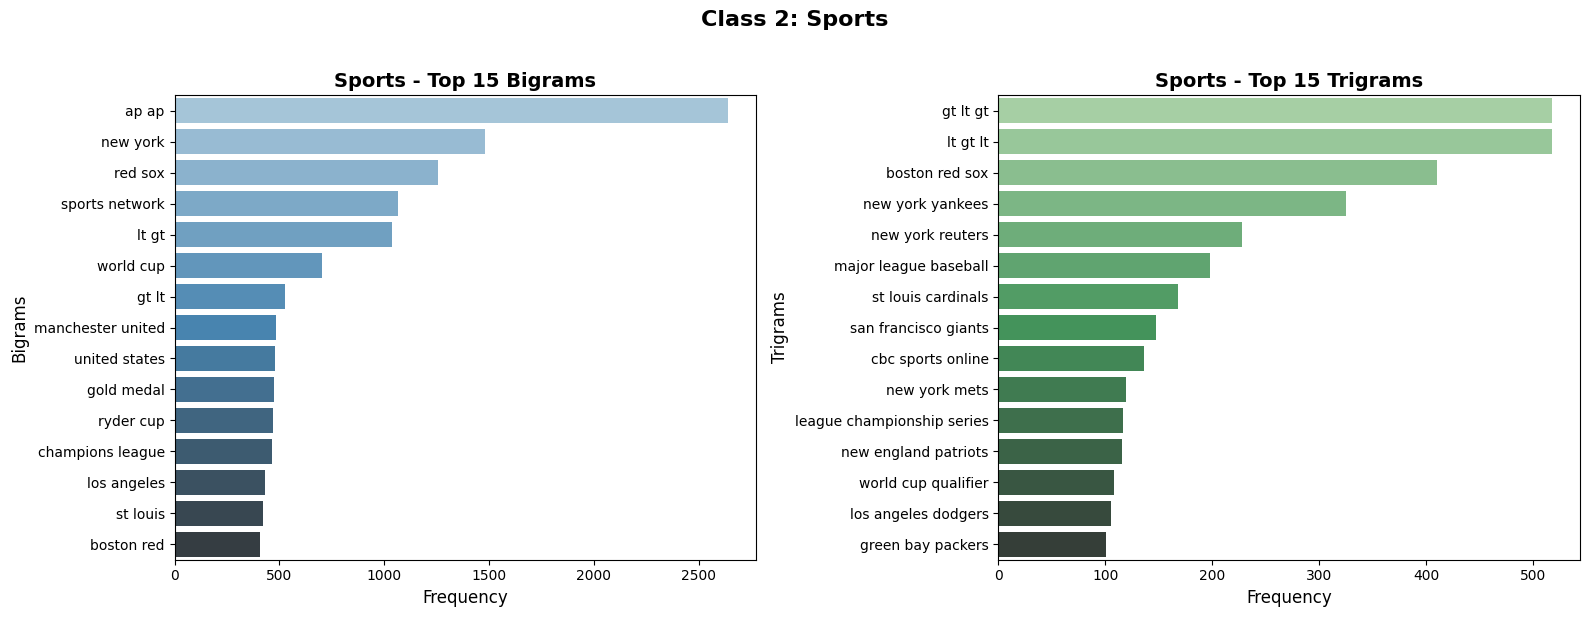

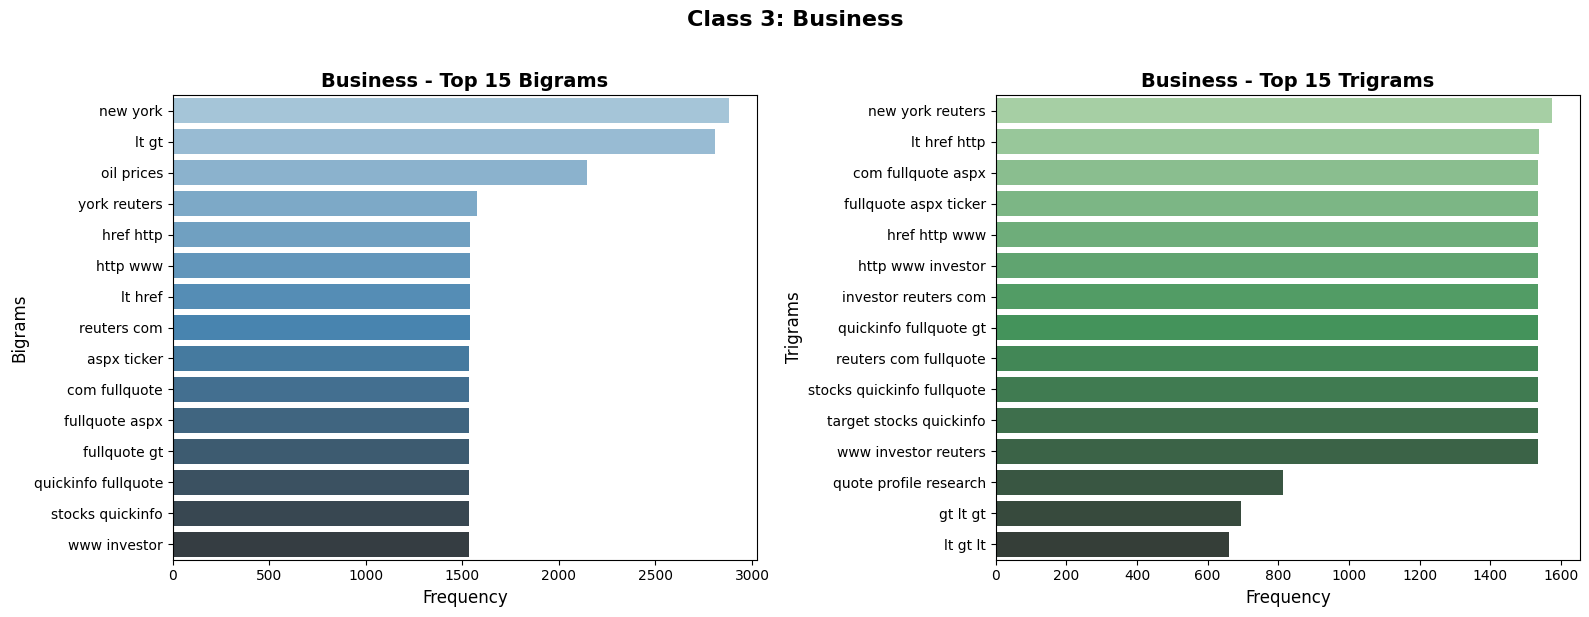

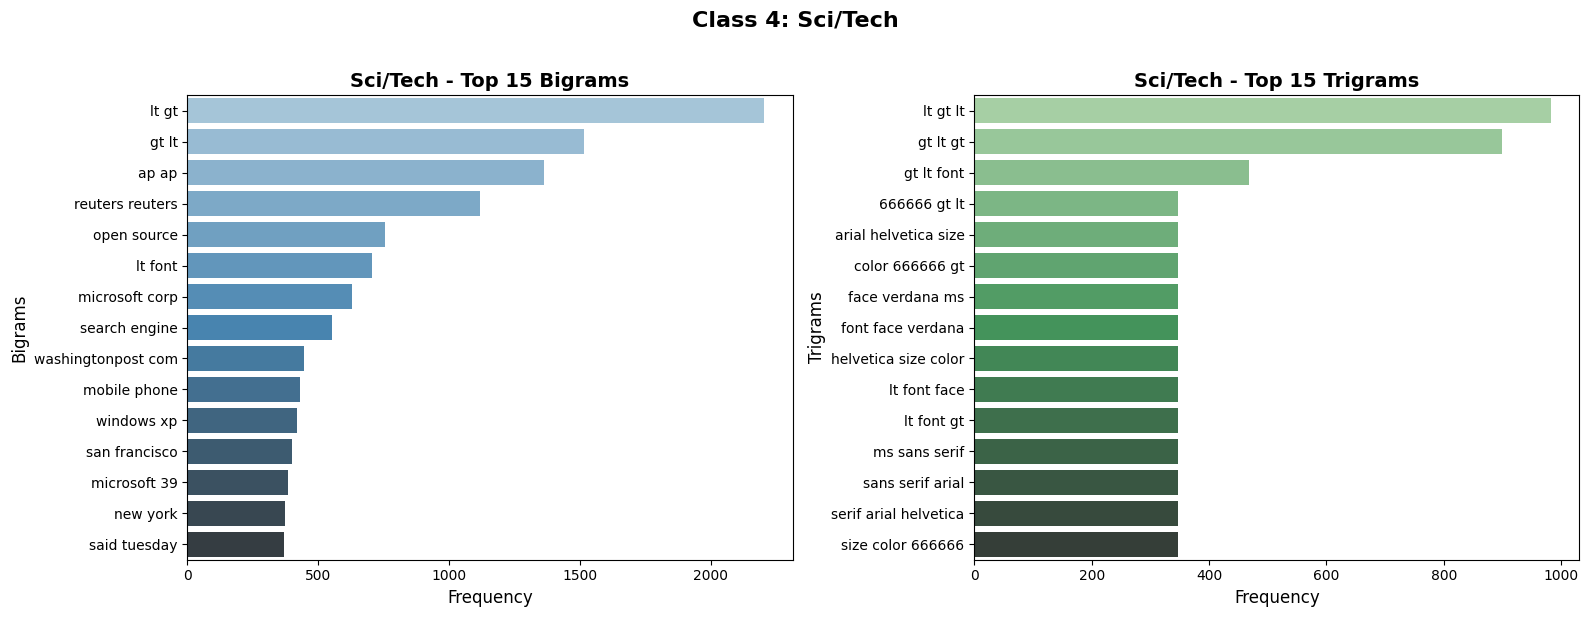

In [118]:
# Định nghĩa mapping cho class names
class_names = {
    1: 'World',
    2: 'Sports',
    3: 'Business',
    4: 'Sci/Tech'
}

# ============================================
# 1. TRỰC QUAN CHO TOÀN BỘ DATASET
# ============================================

def plot_ngrams_global(df, text_col='text', top_n=20):
    """
    Vẽ bigram và trigram cho toàn bộ dataset
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # ---- BIGRAM ----
    bigram_vec = CountVectorizer(ngram_range=(2,2), max_features=top_n, stop_words='english')
    bigram_X = bigram_vec.fit_transform(df[text_col])
    bigram_freq = np.asarray(bigram_X.sum(axis=0)).ravel()
    bigram_words = bigram_vec.get_feature_names_out()

    # Sắp xếp theo tần suất
    top_bigrams = sorted(zip(bigram_words, bigram_freq), key=lambda x: x[1], reverse=True)
    words_b, freqs_b = zip(*top_bigrams)

    # Vẽ bigram
    sns.barplot(x=list(freqs_b), y=list(words_b), palette='Blues_d', ax=axes[0])
    axes[0].set_title(f'Top {top_n} Bigrams (Global)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Frequency', fontsize=12)
    axes[0].set_ylabel('Bigrams', fontsize=12)

    # ---- TRIGRAM ----
    trigram_vec = CountVectorizer(ngram_range=(3,3), max_features=top_n, stop_words='english')
    trigram_X = trigram_vec.fit_transform(df[text_col])
    trigram_freq = np.asarray(trigram_X.sum(axis=0)).ravel()
    trigram_words = trigram_vec.get_feature_names_out()

    # Sắp xếp theo tần suất
    top_trigrams = sorted(zip(trigram_words, trigram_freq), key=lambda x: x[1], reverse=True)
    words_t, freqs_t = zip(*top_trigrams)

    # Vẽ trigram
    sns.barplot(x=list(freqs_t), y=list(words_t), palette='Greens_d', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Trigrams (Global)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Frequency', fontsize=12)
    axes[1].set_ylabel('Trigrams', fontsize=12)

    plt.tight_layout()
    plt.show()

    return top_bigrams, top_trigrams


# ============================================
# 2. PLOT RIÊNG TỪNG CLASS (SUBPLOTS ĐỘC LẬP)
# ============================================

def plot_ngrams_individual_classes(df, label_col='label', text_col='text', top_n=15):
    """
    Vẽ từng class riêng biệt trong các figure riêng
    """
    classes = sorted(df[label_col].unique())

    for cls in classes:
        df_cls = df[df[label_col] == cls]
        class_name = class_names.get(cls, f'Class {cls}')

        if len(df_cls) == 0:
            print(f"Không có dữ liệu cho class {cls}: {class_name}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Bigram
        bigram_vec = CountVectorizer(ngram_range=(2,2), max_features=top_n, stop_words='english')
        bigram_X = bigram_vec.fit_transform(df_cls[text_col])
        bigram_freq = np.asarray(bigram_X.sum(axis=0)).ravel()
        bigram_words = bigram_vec.get_feature_names_out()

        top_bigrams = sorted(zip(bigram_words, bigram_freq), key=lambda x: x[1], reverse=True)
        if top_bigrams:
            words, freqs = zip(*top_bigrams)
            sns.barplot(x=list(freqs), y=list(words), palette='Blues_d', ax=axes[0])
            axes[0].set_title(f'{class_name} - Top {top_n} Bigrams', fontsize=14, fontweight='bold')
            axes[0].set_xlabel('Frequency', fontsize=12)
            axes[0].set_ylabel('Bigrams', fontsize=12)

        # Trigram
        trigram_vec = CountVectorizer(ngram_range=(3,3), max_features=top_n, stop_words='english')
        trigram_X = trigram_vec.fit_transform(df_cls[text_col])
        trigram_freq = np.asarray(trigram_X.sum(axis=0)).ravel()
        trigram_words = trigram_vec.get_feature_names_out()

        top_trigrams = sorted(zip(trigram_words, trigram_freq), key=lambda x: x[1], reverse=True)
        if top_trigrams:
            words, freqs = zip(*top_trigrams)
            sns.barplot(x=list(freqs), y=list(words), palette='Greens_d', ax=axes[1])
            axes[1].set_title(f'{class_name} - Top {top_n} Trigrams', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Frequency', fontsize=12)
            axes[1].set_ylabel('Trigrams', fontsize=12)

        plt.suptitle(f'Class {cls}: {class_name}', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

# ============================================
# 5. THỰC THI
# ============================================

# Vẽ cho toàn bộ dataset
top_bigrams, top_trigrams = plot_ngrams_global(train_df, text_col='text', top_n=20)

# Vẽ từng class riêng biệt
plot_ngrams_individual_classes(train_df, label_col='label', text_col='text', top_n=15)

# Phân tích từ khóa phân biệt (Discriminating words)

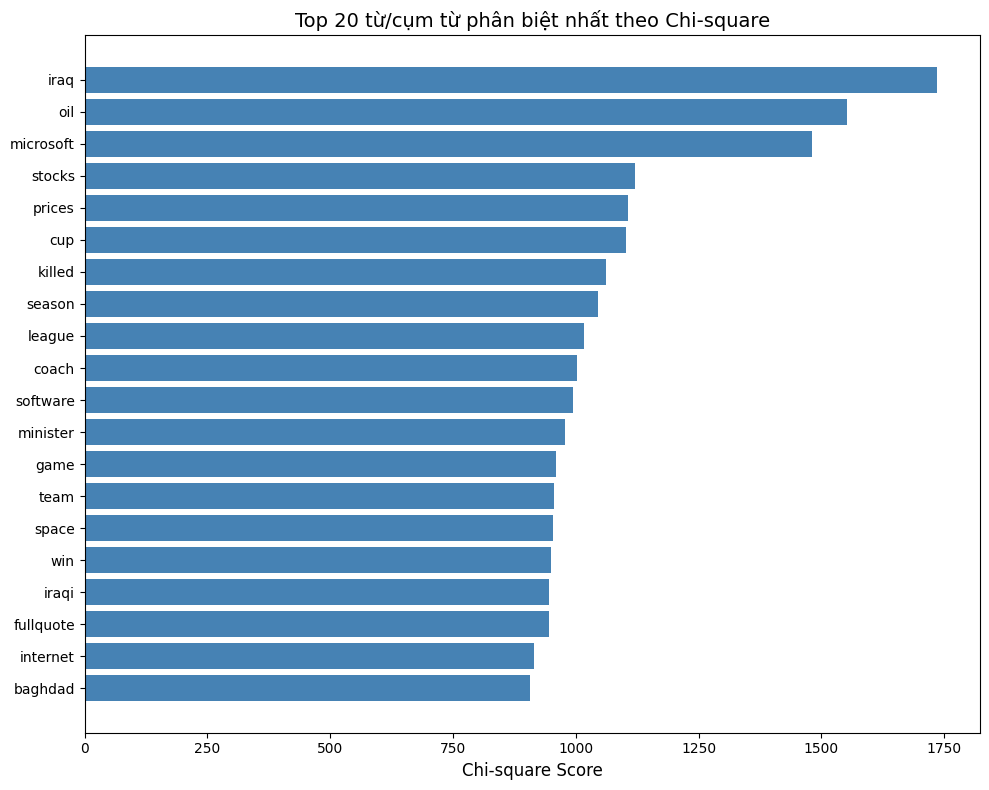

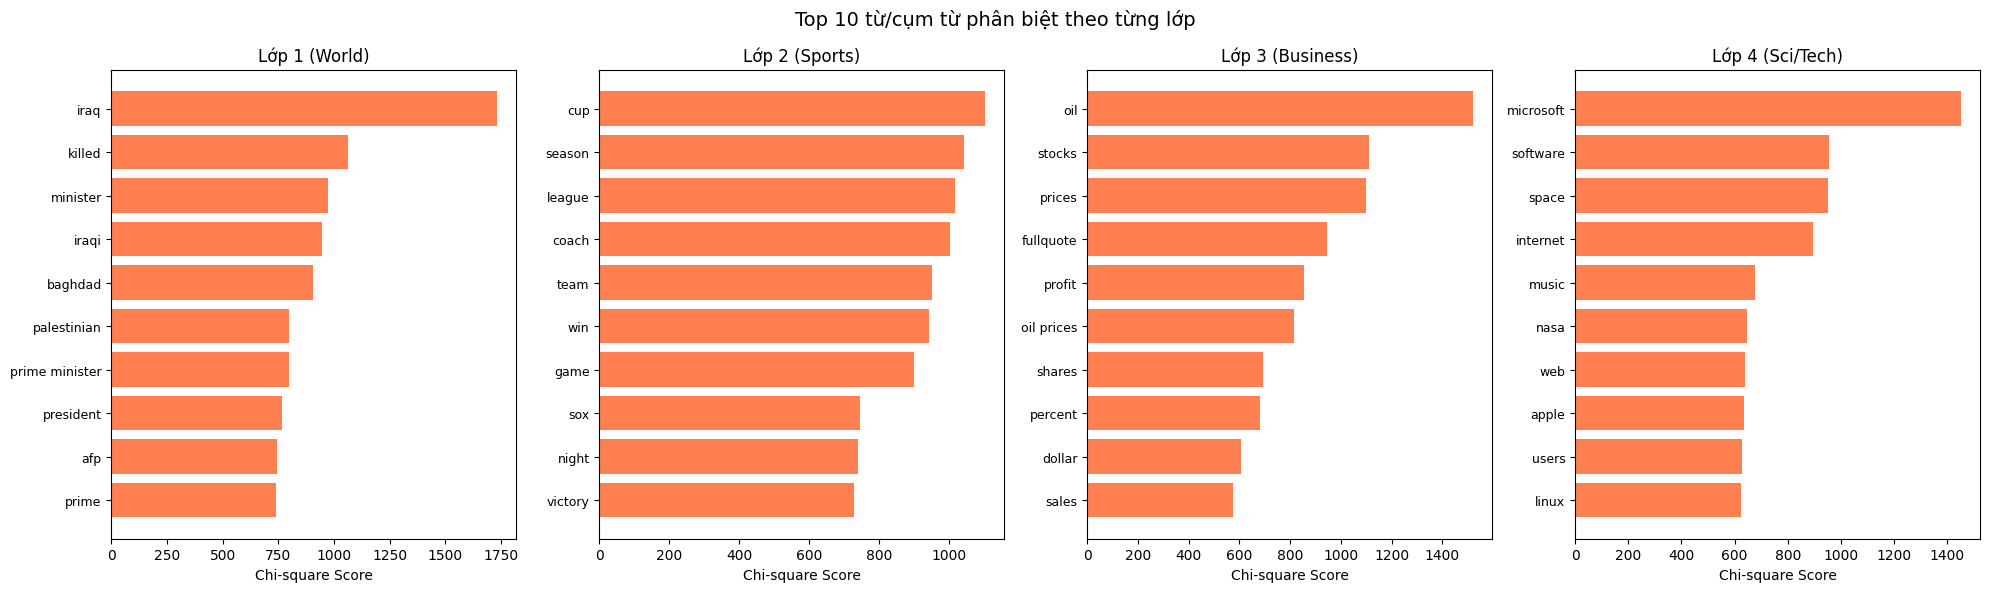

In [119]:
# Giả sử bạn đã có df và class_names
# Chuẩn bị TF-IDF để chọn từ khóa phân biệt cao
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(train_df['text'])
y = train_df['label'].values

chi2_scores, p_vals = chi2(X_tfidf, y)
feature_names = tfidf.get_feature_names_out()

# === Biểu đồ 1: Top 20 từ/cụm từ phân biệt nhất chung ===
chi2_per_feature = list(zip(feature_names, chi2_scores))
chi2_per_feature_sorted = sorted(chi2_per_feature, key=lambda x: x[1], reverse=True)[:20]

words_top20 = [item[0] for item in chi2_per_feature_sorted][::-1]
scores_top20 = [item[1] for item in chi2_per_feature_sorted][::-1]

plt.figure(figsize=(10, 8))
plt.barh(words_top20, scores_top20, color='steelblue')
plt.xlabel('Chi-square Score', fontsize=12)
plt.title('Top 20 từ/cụm từ phân biệt nhất theo Chi-square', fontsize=14)
plt.tight_layout()
plt.show()

# === Biểu đồ 2: Top từ riêng cho từng lớp (Thanh ngang) ===
fig, axes = plt.subplots(1, len(np.unique(y)), figsize=(5*len(np.unique(y)), 6), squeeze=False)
axes = axes.flatten()

for i, cls in enumerate(np.unique(y)):
    y_binary = (y == cls).astype(int)
    selector = SelectKBest(chi2, k=10).fit(X_tfidf, y_binary)
    top_indices = np.argsort(selector.scores_)[-10:][::-1]

    top_words = [feature_names[idx] for idx in top_indices][::-1]
    top_scores = [selector.scores_[idx] for idx in top_indices][::-1]

    axes[i].barh(top_words, top_scores, color='coral')
    axes[i].set_xlabel('Chi-square Score', fontsize=10)
    axes[i].set_title(f'Lớp {cls} ({class_names[cls]})', fontsize=12)
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Top 10 từ/cụm từ phân biệt theo từng lớp', fontsize=14)
plt.tight_layout()
plt.show()

## Kiểm tra dữ liệu bất thường / nhiễu

In [120]:
# Kiểm tra dòng có số từ quá ngắn (< 3 từ)
short_texts = train_df[train_df['word_count'] < 3]
print(f"Số văn bản có ít hơn 3 từ: {len(short_texts)}")
if len(short_texts) > 0:
    print("Ví dụ:")
    print(short_texts[['label', 'text']].head())

# Kiểm tra ký tự đặc biệt, số, HTML tags
def count_special_chars(text):
    # Đếm tỉ lệ ký tự không phải chữ cái, khoảng trắng
    text = str(text)
    letters_spaces = sum(c.isalpha() or c.isspace() for c in text)
    return 1 - (letters_spaces / len(text)) if len(text)>0 else 0

train_df['special_ratio'] = train_df['text'].apply(count_special_chars)
print(f"\nTỉ lệ ký tự đặc biệt trung bình: {train_df['special_ratio'].mean():.4f}")
print(train_df['special_ratio'].describe())

# Phát hiện dòng có HTML
html_pattern = re.compile(r'<[^>]+>')
has_html = train_df['text'].apply(lambda x: bool(html_pattern.search(str(x))))
print(f"\nSố dòng chứa HTML tags: {has_html.sum()}")

Số văn bản có ít hơn 3 từ: 0

Tỉ lệ ký tự đặc biệt trung bình: 0.0425
count    102080.000000
mean          0.042458
std           0.027533
min           0.000000
25%           0.023179
50%           0.036630
75%           0.055300
max           0.315136
Name: special_ratio, dtype: float64

Số dòng chứa HTML tags: 0


## Thống kê sau tiền xử lý (đối sánh)

In [121]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, use_stemming=True):
    text = str(text).lower()
    # Loại bỏ punctuation và số
    text = re.sub(f"[{string.punctuation}]", " ", text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    # Loại stopword
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Áp dụng tiền xử lý (stemming)
train_df['clean_text'] = train_df['text'].apply(lambda x: preprocess_text(x, use_stemming=True))

# So sánh số từ duy nhất và độ dài trung bình trước/sau
train_df['clean_word_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))
all_clean_tokens = []
for tokens in train_df['clean_text'].apply(lambda x: x.split()):
    all_clean_tokens.extend(tokens)
unique_clean = set(all_clean_tokens)

print("=== So sánh trước và sau tiền xử lý ===")
print(f"Số từ duy nhất ban đầu: {len(unique_words)}")
print(f"Số từ duy nhất sau xử lý: {len(unique_clean)}")
print(f"Độ dài trung bình số từ ban đầu: {train_df['word_count'].mean():.2f}")
print(f"Độ dài trung bình sau xử lý: {train_df['clean_word_count'].mean():.2f}")

# Top từ sau xử lý
clean_freq = Counter(all_clean_tokens)
print("\nTop 20 từ sau tiền xử lý:")
for word, freq in clean_freq.most_common(20):
    print(f"{word}: {freq}")

=== So sánh trước và sau tiền xử lý ===
Số từ duy nhất ban đầu: 61373
Số từ duy nhất sau xử lý: 48960
Độ dài trung bình số từ ban đầu: 37.86
Độ dài trung bình sau xử lý: 24.76

Top 20 từ sau tiền xử lý:
new: 18231
said: 17119
reuter: 16332
year: 12292
quot: 9449
two: 8752
compani: 8595
first: 8406
say: 7495
world: 7440
game: 7165
one: 6963
report: 6892
monday: 6457
oil: 6355
tuesday: 6319
wednesday: 6288
thursday: 6131
week: 6059
price: 5983


# Kết luận

- Phân phối nhãn cân bằng
- chọn max_len = 64 (có thể cao hơn)
- Số lượng tokens: 61373 → kích thước từ điển cho embedding layer.
---
- Không có NULL, Duplicates
- Có nhiễu → Cần clean nhẹ:
  - Lỗi dính từ (Missing Spaces)
  - Rác HTML/XML (HTML Tags Leakage)
  - Ký tự Escape và Backslash dư thừa
---
- Từ Chi-square → các lớp có từ khóa riêng biệt
  - Lớp 1 (World): Tập trung vào chính trị và xung đột
  - Lớp 2 (Sports): Mang tính đặc thù cao nhất với các thuật ngữ thể thao rõ rệt (cup, season, league, team, win).
  - Lớp 3 (Business): Liên quan chặt chẽ đến tài chính và thị trường (oil, stocks, prices, profit, shares).
  - Lớp 4 (Sci/Tech): Gồm các thực thể công nghệ và khoa học (microsoft, software, space, nasa).

**Kết luận**: Bài toán phân loại này có tính khả thi rất cao vì sự giao thoa (overlap) giữa các từ khóa quan trọng nhất của mỗi lớp là rất thấp.

- Từ phân tích Bigrams và Trigrams:
  - Có nhiều cụm từ mang sắc thái ngữ nghĩa quan trọng mà Unigram (từ đơn) có thể bỏ lỡ:
    - World: "prime minister", "united nations", "president bush".
    - Business: "oil prices", "reuters com", "fullquote aspx" (liên quan đến dữ liệu chứng khoán).
    - Sports: "red sox", "world cup", "champions league".
    - Sci/Tech: "open source", "microsoft corp", "search engine".
  - Nhiễu kỹ thuật (Noise): Có rất nhiều cụm từ xuất hiện với tần suất cực cao nhưng không mang lại giá trị phân loại, chủ yếu là do quá trình thu thập dữ liệu (web scraping):
    - HTML/Kỹ thuật: lt gt (thực chất là dấu < >), href http, http www, com fullquote, aspx ticker.
    - Định dạng/Màu sắc: 666666 gt lt, arial helvetica size, color 666666.
    - Nguồn tin: ap ap, reuters reuters, afp afp.

**Cần thực hiện CLEAN NHẸ**:
  - Loại bỏ HTML Entities: Các cụm như \&lt;, \&gt;, \&amp;, \&quot; (trong biểu đồ hiện ra là lt, gt).
  - Web Artifacts & CSS:
    - URL/Links: http, www, https, href, aspx, com.
    - CSS Styles: color, 666666 (mã màu), font-family, arial, verdana, size.
  - Source Tags & Duplicates: Các từ lặp như ap ap, reuters reuters, afp afp và tên các hãng tin ở đầu bài.

---


### 1. Bước 1: Khôi phục thực thể HTML (Unescape)
Đây là bước quan trọng nhất để giải quyết triệt để các cụm `lt gt` đang đứng đầu bảng tần suất.
* **Hành động:** Sử dụng `html.unescape()` để chuyển các chuỗi như `&lt;`, `&gt;`, `&amp;` về đúng ký tự gốc là `<`, `>`, `&`.
* **Lý do:** Tránh việc bộ tách từ (tokenizer) hiểu lầm các ký tự này là từ đơn (`lt`, `gt`) và đưa chúng vào tập đặc trưng quan trọng.

### 2. Bước 2: Loại bỏ mã độc hại và rác hệ thống (Web Scraping Artifacts)
Dữ liệu của bạn cho thấy dấu vết rõ rệt của CSS và cấu trúc trang web.
* **Loại bỏ HTML Tags:** Dùng Regex xóa các thẻ trong ngoặc nhọn (ví dụ: `<div>`, `<p>`).
* **Loại bỏ CSS/Style:** Xóa các mã màu Hex (ví dụ: `#666666`), tên font chữ (`arial`, `helvetica`, `sans-serif`) và các thuộc tính định dạng (`size`, `color`).
* **Loại bỏ URL & Email:** Sử dụng Regex để quét và xóa toàn bộ các đường dẫn `http`, `www`, `.aspx` xuất hiện trong văn bản.

### 3. Bước 3: Xử lý nhiễu từ nguồn tin (Agency Noise)
Các hãng tin thường để lại "dấu vân tay" làm sai lệch tần suất từ.
* **Hành động:** Loại bỏ hoặc chuẩn hóa các tên hãng tin lặp lại ở đầu bài báo như `ap ap`, `reuters reuters`, `afp afp`.
* **Lý do:** Những từ này không đóng góp vào ngữ cảnh chủ đề mà chỉ phản ánh nguồn gốc dữ liệu.

### 4. Bước 4: Chuẩn hóa văn bản (Text Normalization)
* **Xử lý khoảng trắng:** Loại bỏ các ký tự xuống dòng `\n`, tab `\t` và đưa các khoảng trắng dư thừa về một khoảng trắng duy nhất.
* **Xử lý ký tự đặc biệt:** Xóa các ký tự Escape và Backslash dư thừa đã được phát hiện trong bước EDA.

---

### 5. Bước 5: Phân tách chiến lược theo mô hình (Model-Specific)
Sau khi có "văn bản sạch", bạn cần điều chỉnh tùy theo loại mô hình sử dụng:

| Tính năng | ML Truyền thống (TF-IDF) | Deep Learning (LSTM/CNN) | BERT / Transformers |
| :--- | :--- | :--- | :--- |
| **Lowercasing** | **Cần thiết** để giảm chiều dữ liệu. | **Cần thiết**. | Tùy bản BERT (cased/uncased). |
| **Stopwords** | **Nên xóa** các từ quá phổ biến. | **Cân nhắc** giữ lại để bảo toàn mạch câu. | **Bắt buộc giữ** để hiểu ngữ cảnh sâu. |
| **Punctuation** | **Nên xóa** sạch. | **Nên xóa**. | **Bắt buộc giữ** (dấu chấm, phẩy giúp BERT hiểu cấu trúc câu). |
| **Stem/Lemmatize** | **Rất tốt** để gộp nhóm từ (như `run`, `running`). | **Ít dùng** (để mô hình tự học từ Embedding). | **Không dùng** (BERT dùng WordPiece cho từ gốc). |

---

### Tóm tắt luồng xử lý (Workflow) gợi ý:

1.  **Hàm Clean chung (Dùng cho cả 3):** Unescape HTML $\rightarrow$ Xóa Tags/CSS/URL $\rightarrow$ Xóa Agency Noise $\rightarrow$ Chuẩn hóa khoảng trắng.
2.  **Cho TF-IDF:** Clean chung $\rightarrow$ Lowercase $\rightarrow$ Xóa Stopwords/Punctuation $\rightarrow$ Stemming.
3.  **Cho BERT:** Clean chung $\rightarrow$ (Giữ nguyên dấu câu, viết hoa, từ nối) $\rightarrow$ Đưa thẳng vào BERT Tokenizer.



Việc tuân thủ checklist này sẽ giúp bạn loại bỏ hoàn toàn các đặc trưng rác như `lt gt` hay `666666`, giúp mô hình tập trung vào các từ khóa "vàng" như `iraq`, `stocks`, hay `microsoft` mà bạn đã tìm thấy qua Chi-square.

Bạn có muốn tôi hỗ trợ viết một hàm Python hoàn chỉnh tích hợp tất cả các bước trên để bạn thay thế vào file EDA hiện tại không?